In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
import CMR_IA as cmr

cmr.analysis.setup_notebook()

SAVEFIG = False
SAVEDATA = False

In [2]:
# Load correct recall data
df_corr = pd.read_csv("data/simu8_Pantelis_correct.csv", header=None)
df_corr

,0,1,2,3
0,1.00885,0.806870,0,mean
1,1.00000,0.858779,0,sd+
2,1.00000,0.754198,0,sd-
3,2.00000,0.765649,1,mean
4,2.00000,0.804580,1,sd+
5,2.00000,0.727481,1,sd-
6,3.00000,0.674809,2,mean
7,3.00000,0.707634,2,sd+
8,3.00000,0.642748,2,sd-
9,4.00000,0.640458,3,mean


In [3]:
# Pivot correct recall table
df_corr = df_corr.pivot_table(index=2, columns=3, values=1).reset_index(drop=True)
df_corr

3,mean,sd+,sd-
0,0.806870,0.858779,0.754198
1,0.765649,0.804580,0.727481
2,0.674809,0.707634,0.642748
3,0.640458,0.677099,0.603053
4,0.606107,0.648092,0.563359
5,0.567939,0.629008,0.505344


In [4]:
# Compute SD and format X/Y columns
df_corr["SD1"] = df_corr[" sd+"] - df_corr[" mean"]
df_corr["SD2"] = df_corr[" mean"] - df_corr[" sd-"]
df_corr["SD"] = df_corr[["SD1", "SD2"]].mean(axis=1)
df_corr["X"] = ["1", "2", "3", "4", "5", "6-7"]
df_corr["Y"] = df_corr[" mean"]
df_corr

3,mean,sd+,sd-,SD1,SD2,SD,X,Y
0,0.806870,0.858779,0.754198,0.051908,0.052672,0.052290,1,0.806870
1,0.765649,0.804580,0.727481,0.038931,0.038168,0.038550,2,0.765649
2,0.674809,0.707634,0.642748,0.032824,0.032061,0.032443,3,0.674809
3,0.640458,0.677099,0.603053,0.036641,0.037405,0.037023,4,0.640458
4,0.606107,0.648092,0.563359,0.041985,0.042748,0.042366,5,0.606107
5,0.567939,0.629008,0.505344,0.061069,0.062595,0.061832,6-7,0.567939


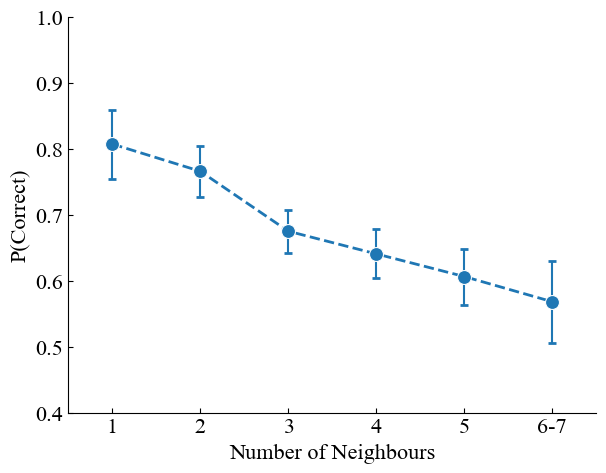

In [5]:
# Plot correct recall by neighbour group
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.errorbar(x=df_corr["X"], y=df_corr["Y"], yerr=df_corr["SD"], marker=None, capsize=3, capthick=2, linestyle="none")
sns.lineplot(data=df_corr, y="Y", x="X", ax=ax, marker="o", color="C0", markersize=10, linewidth=2, linestyle="--")

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
plt.ylim([0.4, 1])
plt.xlim([-0.5, 5.5])
plt.xticks(ticks=np.arange(0, 6), labels=["1", "2", "3", "4", "5", "6-7"])
plt.xlabel("Number of Neighbours")
plt.ylabel("P(Correct)")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.savefig("figures/simu8_Pantelis_correct.pdf")
plt.show()

In [6]:
# Load ILI data
df_ILI = pd.read_csv("data/simu8_Pantelis_ILI.csv", header=None)
df_ILI

,0,1,2,3
0,0.995069,0.151485,0,mean
1,0.995069,0.175248,0,sd+
2,0.995069,0.127723,0,sd-
3,1.493097,0.163119,1,mean
4,1.493097,0.179703,1,sd+
5,1.493097,0.145792,1,sd-
6,1.996055,0.052228,2,mean
7,1.996055,0.059653,2,sd+
8,1.996055,0.044554,2,sd-
9,2.499014,0.048515,3,mean


In [7]:
# Pivot ILI table
df_ILI = df_ILI.pivot_table(index=2, columns=3, values=1).reset_index(drop=True)
df_ILI

3,mean,sd+,sd-
0,0.151485,0.175248,0.127723
1,0.163119,0.179703,0.145792
2,0.052228,0.059653,0.044554
3,0.048515,0.054455,0.042327
4,0.038861,0.045297,0.032178
5,0.020545,0.023762,0.017079
6,0.013861,0.016089,0.011139


In [8]:
# Compute SD and format X/Y columns for ILI
df_ILI["SD1"] = df_ILI[" sd+"] - df_ILI[" mean"]
df_ILI["SD2"] = df_ILI[" mean"] - df_ILI[" sd-"]
df_ILI["SD"] = df_ILI[["SD1", "SD2"]].mean(axis=1)
df_ILI["X"] = ["1.0", "1.5", "2.0", "2.5", "3.0", "3.5", ">3.5"]
df_ILI["Y"] = df_ILI[" mean"]
df_ILI

3,mean,sd+,sd-,SD1,SD2,SD,X,Y
0,0.151485,0.175248,0.127723,0.023762,0.023762,0.023762,1.0,0.151485
1,0.163119,0.179703,0.145792,0.016584,0.017327,0.016955,1.5,0.163119
2,0.052228,0.059653,0.044554,0.007426,0.007673,0.007550,2.0,0.052228
3,0.048515,0.054455,0.042327,0.005941,0.006188,0.006064,2.5,0.048515
4,0.038861,0.045297,0.032178,0.006436,0.006683,0.006559,3.0,0.038861
5,0.020545,0.023762,0.017079,0.003218,0.003465,0.003342,3.5,0.020545
6,0.013861,0.016089,0.011139,0.002228,0.002723,0.002475,>3.5,0.013861


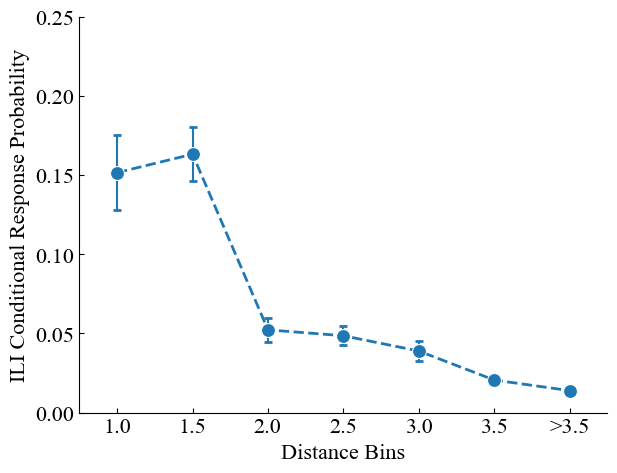

In [9]:
# Plot ILI by neighbour group
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.errorbar(x=df_ILI["X"], y=df_ILI["Y"], yerr=df_ILI["SD"], marker=None, capsize=3, capthick=2, linestyle="none")
sns.lineplot(data=df_ILI, y="Y", x="X", ax=ax, marker="o", color="C0", markersize=10, linewidth=2, linestyle="--")

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
plt.ylim([0, 0.25])
plt.xlim([-0.5, 6.5])
plt.xticks(ticks=np.arange(0, 7), labels=["1.0", "1.5", "2.0", "2.5", "3.0", "3.5", ">3.5"])
plt.xlabel("Distance Bins")
plt.ylabel("ILI Conditional Response Probability")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.savefig("figures/simu8_Pantelis_ILI.pdf")
plt.show()

In [10]:
# Save gt as json
if SAVEDATA:
    with open("data/simu8_gt.json", "w") as f:
        json.dump(
            {
                "neighbor_mean": df_corr["Y"].to_numpy().tolist(),
                "neighbor_se": df_corr["SD"].to_numpy().tolist(),
                "ILI_mean": df_ILI["Y"].to_numpy().tolist(),
                "ILI_se": df_ILI["SD"].to_numpy().tolist(),
            },
            f,
            indent=4,
        )